# Model Fitting and Optimization

## Linear Regression

### Linear Regression Model and OLS
- Model:
    - The linear regression model assumes a parametric form of the distribution of the target variable
    - $Y \mid X \sim \mathcal{N}\!\left(X\beta,\; \sigma^2 I_n\right)$
    - Parameters: $\beta$
- Estimation:
    - We estimate $\beta$ through chosing the parameter that minimizes a loss function (objective function) 
    - Loss function: MSE $L(\beta) = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - X_i \beta \right)^2 = \frac{1}{n} (y - X\beta)^{\top} (y - X\beta)$
    - Estimate linear regression model through minimizing MSE is called OLS
- Analytical solution:
    - Setting the gradient of the loss function with respect $\beta$ to zero
    - $0 = \nabla_{\beta} \!\left[y^{\top} y- 2 \beta^{\top} X^{\top} y+ \beta^{\top} X^{\top} X \beta\right]= -2 X^{\top} y + 2 X^{\top} X \beta$
    - This yields the analytical solution:
    - $\hat{\beta} = \left( X^{\top} X \right)^{-1} X^{\top} y$
- For most ML models, a closed-form analytical solution does not exist
- Therefore, alternative methods to minimize the loss function and learn parameters are needed
- These methods are called model fitting methods

### Linear Regression Using Scikit-Learn

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression

X_train = np.random.randn(100, 1)
intercept_true = 5.0
beta_true = 1.5
y_train = X_train[:, 0] * beta_true + intercept_true + np.random.randn(100) * 0.5

model = LinearRegression()
model.fit(X_train, y_train)
print(model.coef_[0], model.intercept_)

1.5099563347812825 4.960419018454494


## Fitting Model

### Introduction of Optimization Algorithms
- Suppose that there is a loss function $L[ϕ]$ that returns a single number that quantifies the mismatch between prediction and true target values
- The goal of an optimization algorithm is to find parameters $\hat ϕ$ that minimize the loss: $\hat ϕ = argmin_{ϕ}[L[ϕ]]$
- The standard methods for training neural networks are iterative
- These algorithms initialize the parameters randomly and then adjust them repeatedly in such a way that the loss decreases
- The simplest method of this class is gradient descent

### Gradient Descent
- Starts with initial parameters $ϕ = [ϕ_0, ϕ_1, . . . , ϕ_N]^\top$ and iterates following two steps
    - Compute the gradient of the loss with respect to the parameters: 
    $
    \nabla_{\boldsymbol{\phi}}L(\boldsymbol{\phi})
    =
    \begin{bmatrix}
    \frac{\partial L}{\partial \phi_0} \\
    \frac{\partial L}{\partial \phi_1} \\
    \vdots \\
    \frac{\partial L}{\partial \phi_N}
    \end{bmatrix}
    $
    - Update rule: $\boldsymbol{\phi}\leftarrow\boldsymbol{\phi}-\alpha \nabla_{\boldsymbol{\phi}} L(\boldsymbol{\phi})$
- Intuition:
    - The positive scalar $α$ determines the learning rate, which is the setp size of the update
    - The gradient $\nabla_{\boldsymbol{\phi}}$ gives the direction along each paremeter that the loss function increases fastest
    - So updating in the opposite direction of $\nabla_{\boldsymbol{\phi}}$ should lead to quickest decline in loss until reaching the minimum
    - At the minimum of the loss function, the surface must be flat, the gradient will be zero, and the parameters will stop changing
- Limitation:
    - Loss functions are generally non-convex, having multiple local minima:
        - When reaching one local minima, as the gradient (slope of surface) will be zero, the algorithm will stop updating
        - There is no guarantee that the parameters will stop updating at the local minima that is also the global minimum
    - Loss functions may also have saddle points:
        - At saddle points, the gradient is zero, but the function increases in some directions and decreases in others
        - The algorithm may again stop updating the parameter at the saddle point

### Stochastic Gradient Descent
- Why SGD:
    - One of the main problems of GD is that the final destination is not necessary the global minimum
    - The local minima the parameters finally arrive is entirely determined by the starting point
    - Stochastic gradient descent (SGD) attempts to remedy this problem by adding some noise to the gradient (direction of update) at each step
    - The solution still moves downhill on average, but the direction at single update is not necessarily in the steepest downhill direction
- SGD Algorithm:
    - At each iteration, the algorithm chooses a random subset of the training data and computes the gradient of loss function for each observation from these data
    - This subset is known as a **minibatch** or **batch**
    - The algorithm then updates the parameter in a direction derived through combining these derivatives:
    - $\boldsymbol{\phi}_{t+1} \leftarrow \boldsymbol{\phi}_{t} - \alpha \sum_{i \in B_t} \nabla_{\boldsymbol{\phi}} l_i(\boldsymbol{\phi_t; x_i, y_i})$
    - $B_t$ is the set containing the indices of the input/output pairs in the current batch
    - $l_i$ is the loss due to the ith output and prediction
    - The term $α$ is the learning rate
- Batch and epoch:
    - The batches are usually drawn from the dataset without replacement
    - The algorithm works through the training set until it has used all data, at which point it starts sampling from the full training set again
    - A single pass through the entire training dataset is referred to as an **epoch**
- Attractive features:
    - Although it adds noise to the update (by combing multiple direction of update), it still improves the fit at each iteration
    - It can (in principle) escape local minima due to the randomness introduced
    - It also reduces the chances of getting stuck near saddle points
    - Empirical evidence shows that SGD finds parameters for neural networks that cause them to generalize well to new data
- Convergence:
    - SGD does not necessarily “converge” in the traditional sense
    - However, the hope is that when close to the global minimum, all the data points will be well predicted
    - Consequently, the gradient will be small, whichever batch is chosen, the parameters will not change much (oscillates around the global minimum)
    - In practice, SGD is often applied with a decreasing learning rate schedule
    - The logic is that in the early stages, the algorithm can jump from valley to valley to prevent local minimas and find a good region to approach global minimum
    - In later stages, the algorithm is roughly in the right place and are more concerned with small-change of the parameters

### Momentum
- A common modification to SGD is to add a momentum term to reduce oscillatory behavior (and thus increases the speed of convergence)
- Momentum means that the update on parameters is a weighted combination of the gradient (computed from current batch) and direction moved in the previous step
- Algorithm:
    - $m_{t+1} \leftarrow \beta m_t + (1 - \beta) \sum_{i \in \mathcal{B}_t} \frac{\partial \ell_i(\phi_t)}{\partial \phi}$
    - $\phi_{t+1} \leftarrow \phi_t - \alpha m_{t+1}$
    - $m_t$ is the momentum, which is the previous update (at iteration t)
    - $\beta \in [0, 1)$ controls the impact from previous update on current update
- Properties:
    - The recursive formulation of the momentum calculation means that the update is an infinite weighted sum of all the previous gradients
    - The weights get smaller as we move back in time
    - The effective learning rate increases if all these gradients are aligned over multiple iterations
    - It decreases if the gradient direction repeatedly changes
    - The overall effect is a smoother trajectory of updating and reduced oscillatory behavior in valleys 
    - The degree of smootheness is controlled by parameter $\beta$

### Nesterov Accelerated Momentum
- The momentum term can be considered a coarse prediction of where the SGD algorithm will move next
- Nesterov accelerated momentum computes the gradients at this predicted point rather than at the current point
- Another way to think about this is that the gradient term now corrects the path provided by momentum alone
- Algorithm:
    - $m_{t+1} \leftarrow \beta m_t + (1 - \beta) \sum_{i \in \mathcal{B}_t} \frac{\partial \ell_i(\phi_t - \alpha \beta m_t)}{\partial \phi}$
    - $\phi_{t+1} \leftarrow \phi_t - \alpha m_{t+1}$

### Momentum v.s. Nesterov Accelerated Momentum
![my plot](images/2_1.png)

### Adaptive Moment Estimation (Adam)
- Why Adam:
    - Gradient descent with a fixed step size has the following undesirable property: 
        - It makes large adjustments to parameters associated with large gradients
        - Small adjustments to parameters associated with small gradients 
        - Hence, if learning rate small, parameters with overall large gradient will quickly converge, while the one with small gradient will take a long time
        - If learning rate large, parameters with overall small gradient will quickly converge, while the one with large gradient will oscillates and never converge
        - It is difficult to choose a learning rate that makes good progress in both directions
    - A straightforward approach is to normalize the gradients so that move will have fixed distance (governed by the learning rate) in each direction:
        - $m_{t+1} \leftarrow \frac{\partial L(\phi_t)}{\partial \phi}$, is the gradient
        - $v_{t+1} \leftarrow \left(\frac{\partial L(\phi_t)}{\partial \phi}\right)^2$, is the size of the gradient
        - $\phi_{t+1} \leftarrow \phi_t - \alpha \frac{m_{t+1}}{\sqrt{v_{t+1} + \epsilon}}$, normalize gradient by its size
        - $ϵ$ is a small constant that prevents division by zero when the gradient magnitude is zero
    - The result is that the algorithm moves a fixed distance $α$ along each parameter in each iteration
    - This simple algorithm makes good progress but will bounce back and forth (may never converge)
    - To tackle this, adaptive moment estimation takes this idea and adds momentum to both the estimate of the gradient and the squared gradient
    - It also combines the idea of SGD through estimating gradients from observations in batch
- Algorithm:
    - $m_{t+1} \leftarrow \beta m_t + (1 - \beta) \sum_{i \in \mathcal{B}_t} \frac{\partial \ell_i(\phi_t)}{\partial \phi}$, estimate of combined gradient
    - $v_{t+1} \leftarrow \gamma v_t + (1 - \gamma) \left( \sum_{i \in \mathcal{B}_t} \frac{\partial \ell_i(\phi_t)}{\partial \phi} \right)^2$, size of combined gradient
    - $β$ and $γ$ are the momentum coefficients for the two statistics
    - At the start of the fitting, all the previous measurements of $m$ and $v$ are zero, resulting in unrealistically small estimates
    - Consequently, we modify these statistics using the rule:
    - $\tilde{m}_{t+1} \leftarrow \frac{m_{t+1}}{1 - \beta^{\,t+1}}$
    - $\tilde{v}_{t+1} \leftarrow \frac{v_{t+1}}{1 - \gamma^{\,t+1}}$
    - Since $β$ and $γ$ are in the range $[0, 1)$, the terms with exponents $t + 1$ become smaller ith each iteration
    - The denominators become closer to one after time, meaning that this modification has a diminishing effect
    - Finally, we update the parameters as before: $$\phi_{t+1} \leftarrow \phi_t - \alpha \frac{\tilde{m}_{t+1}}{\sqrt{\tilde{v}_{t+1} + \epsilon}}$$
- Properties:
    - The algorithm can converge to the overall minimum and makes good progress in every direction in the parameter space
    - Adam also does not need complex learning rate schedule


## Pytorch

### Set Up

In [1]:
import torch
from torch import nn
import torch.optim as optim
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Compose, Grayscale
import random

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps") # Apple Silicon Metal Performance Shaders
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # GPU
else:
    DEVICE = torch.device("cpu") # CPU

### Tensors
- Tensors are like numpy arrays but GPU-accelerated and can compute gradient automatically
- Tensors “live” on a device

In [5]:
from sklearn import datasets as sk_datasets 
X, y = sk_datasets.load_diabetes(return_X_y =True, as_frame =True)
X = X.iloc[-200:]
y = y.iloc[-200:]
X_train = torch.tensor(X.values, dtype =torch.float32).to(DEVICE)
y_train = torch.tensor(y.values, dtype =torch.float32).to("cpu")
print(X_train.device) 
X_train = X_train.to("cpu")
print(X_train.device)

mps:0
cpu


### Linear regression by OLS

In [6]:
X_with_intercept = torch.cat([torch.ones(X_train.shape[0], 1, dtype=X_train.dtype), X_train], dim=1)
solution = torch.linalg.lstsq(X_with_intercept, y_train.unsqueeze(1)) # lstsq expects RHS shape (n, 1) for single output
coefficients = solution.solution.flatten()   # length 11: intercept, then 10 feature coefs
print("Intercept:", coefficients[0].item())
print("Two coefficients (e.g. bmi, bp):", coefficients[3].item(), coefficients[4].item())

Intercept: 152.05950927734375
Two coefficients (e.g. bmi, bp): 546.1898803710938 408.4148864746094


### Linear regression by Gradient Descent

In [3]:
from torch import nn
import torch.optim as optim

class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, bias=True):
        super().__init__()  # calls constructor of parent class nn.Module
        self.linear = nn.Linear(input_dim, 1, bias=bias) # one linear layer: input_dim -> 1 output

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel(input_dim=X_train.shape[1])
model = model.to(DEVICE) # Model and data must be on the same device
X_train = X_train.to(DEVICE)
y_train = y_train.to(DEVICE)

criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop (enough epochs to approach OLS solution)
epochs = 50000
for epoch in range(epochs): # one epoch = one pass over the entire training set
    # FORWARD PASS: compute predictions and loss.
    outputs = model(X_train) # calls LinearRegressionModel.forward(x)
    loss = criterion(outputs, y_train.unsqueeze(1))  # target shape (n, 1) to match outputs

    # BACKWARD PASS: compute gradients, then update parameters.
    optimizer.zero_grad()  # clear gradients before each backward (otw. they accumulate)
    loss.backward()        # fill gradients for all parameters with requires_grad=True
    optimizer.step()       # update parameters using those gradients

    if (epoch + 1) % 5000 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

# Display the model's coefficients
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'{name}: {param.detach().cpu().numpy()}') # move to CPU for .numpy() if needed

Epoch [5000/50000], Loss: 16587.0625
Epoch [10000/50000], Loss: 8085.0923
Epoch [15000/50000], Loss: 4233.7578
Epoch [20000/50000], Loss: 3450.1555
Epoch [25000/50000], Loss: 3194.4683
Epoch [30000/50000], Loss: 3021.4067
Epoch [35000/50000], Loss: 2902.2144
Epoch [40000/50000], Loss: 2827.0413
Epoch [45000/50000], Loss: 2780.7661
Epoch [50000/50000], Loss: 2756.4556
linear.weight: [[  50.92012  -217.14944   471.3461    426.946     -65.58131    -7.320792
  -270.2626     44.67076   451.45453   -20.139603]]
linear.bias: [151.89885]


### Datasets in PyTorch

100.0%
/opt/anaconda3/envs/ml_econ/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Label: horse
Image size: torch.Size([3, 32, 32])


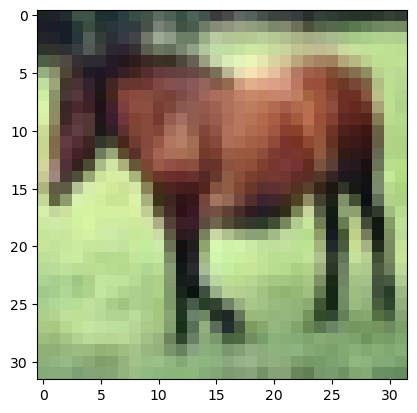

In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.CIFAR10( #  CIFAR-10 is 60k small images in 10 classes.
    root="data",           # directory where data is stored 
    train=True,            # True = training split, False = test split
    download=True,
    transform=ToTensor()   # convert PIL image to tensor, scale pixels to [0, 1]
)
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=ToTensor())

image, label = training_data[7] # Indexing a Dataset returns one sample.
print(f"Label: {training_data.classes[label]}")
print(f"Image size: {image.shape}")   # Image shape is (Channels, Height, Width), e.g. (3, 32, 32) for RGB 32×32. add batch dim later for (N, C, H, W).
plt.imshow(image.permute(1, 2, 0))    # permute to (H, W, C) for matplotlib
plt.show()

### Data Loader

In [ ]:
import numpy 

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    numpy.random.seed(worker_seed)
    random.seed(worker_seed)

g_seed = torch.Generator()
g_seed.manual_seed(torch.initial_seed() % 2**32)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True, num_workers=2)

# Load the next batch
batch_images, batch_labels = next(iter(train_dataloader))
print('Batch size:', batch_images.shape)
plt.imshow(batch_images[0].permute(1, 2, 0))
plt.show()

## Measuring Performance

### Test Error
- For most models, the training error decreases as training proceeds, sometimes the training error may even approaching zero
- However, this doesn’t imply that the model is perfect; the model might have memorized the training set but be unable to predict new observations
- To estimate the true performance, we need a separate **test set** of input/output pairs
- We can then compute the test error as the deviation between model's prediction and the value of output of these new observations
- The difference between test error and train error is a good indicator of how well the model **generalized**

###  Three Sources of Test Error
- Noise:
    - Noise may arise because:
        - There is a genuine stochastic element to the data generation process
        - Some of the data are mislabeled
        - Or because there are further explanatory variables that were not observed
    - Noise is usually a fundamental limitation on the possible test performance, as they cannot be reduced
- Bias:
    - A second potential source of error may occur because the model is not flexible enough to fit the true function perfectly
    - This is known as bias
- Variance:
    - We have limited training examples, and there is no way to distinguish systematic changes from noise in the underlying data
    - When we fit a model, the model learn some noise 
    - For different training datasets, different noise are presented, the model fitted will be slightly different
    - This additional source of variability in the fitted function is termed variance

### Mathematical Formulation of Test Error
- Consider a regression problem where the data generation process has additive noise with variance $σ^2$
- We can observe different outputs y for the same input x, so for each x, the expected value of y is: $\mathbb{E}[y|x]$
- Then define the squares loss between the model prediction $f[x, ϕ]$ at position $x$ and the observed value $y[x]$ at that position as:
$$
\begin{align*}
L[x] & = \left(f[x,\phi] - \mathbb{E}[y|x] + \mathbb{E}[y|x] - y[x] \right)^2 \\ 
& = (f[x,\phi] - \mathbb{E}[y|x])^2 + 2(f[x,\phi] - \mathbb{E}[y|x])(\mathbb{E}[y|x] - y[x]) + (\mathbb{E}[y|x] - y[x])^2
\end{align*}
$$
- The expected square loss at position $x$ is:
$$
\begin{align*}
\mathbb{E}_y[L[x]] & = (f[x,\phi] - \mathbb{E}[y|x])^2 + 2 (f[x,\phi] - \mathbb{E}[y|x])(\mathbb{E}[y|x] - \mathbb{E}[y|x]) + \mathbb{E}_y\left[(\mathbb{E}[y|x] - y[x])^2\right] \\ 
& = (f[x,\phi] - \mathbb{E}[y|x])^2 + 0 +\sigma^2 
\end{align*}
$$
- We can see that the expected square loss has been broken down into two terms:
    - The first term is the squared deviation between the model and the true function mean
    - The second term is the noise
- The parameters $ϕ$ of the model $f[x, ϕ]$ depend on the training dataset $D = {x_i, y_i}$, so more properly, we should write $f[x, ϕ[D]]$
- The training dataset is a random sample as well, hence, we can take expectations of the expected square loss with respect to training data $D$:
$$
\begin{align*}
\mathbb{E}_{D}\left[\mathbb{E}_y\left[L[x]\right]\right] &= \mathbb{E}_{D}\left[(f[x,\phi[D]] - \mathbb{E}[y|x])^2 +\sigma^2 \right] \\
&= \mathbb{E}_{D}\left[(f[x,\phi[D]] - \mathbb{E}_{D}\left[f[x,\phi[D]]\right] + \mathbb{E}_{D}\left[f[x,\phi[D]]\right] - \mathbb{E}[y|x])^2\right] +\sigma^2  \\
& = \mathbb{E}_{D}[(f[x,\phi[D]] - \mathbb{E}_{D}[f[x,\phi[D]]])^2] + 2 \mathbb{E}_{D}[(f[x,\phi[D]] - \mathbb{E}_{D}[f[x,\phi[D]]])(\mathbb{E}_{D}\left[f[x,\phi[D]]\right] - \mathbb{E}[y|x])] + \mathbb{E}_{D}[(\mathbb{E}_{D}\left[f[x,\phi[D]]\right] - \mathbb{E}[y|x])^2] +\sigma^2 \\
& = \mathbb{E}_{D}\left[\left(f[x,\phi[D]] - \mathbb{E}_{D}\left[f[x,\phi[D]]\right]\right)^2 \right] + \left(\mathbb{E}_{D}\left[f[x,\phi[D]]\right] - \mathbb{E}[y|x]\right)^2 +\sigma^2 \\ 
& = \text{Variance} + \text{Bias}^2 + \text{Noise}
\end{align*}
$$
- Variance: measuring the spread of estimators due to randomness in traning set sampling
- Bias: the difference between mean of prediction (w.r.t D) and the population mean of true output
- Noise: randomniess in data generation process
- To reduce test error (improve performance of a model), we can only reduce variance / bias of the model
- This is because the noise component is insurmountable

### Reducing variance
- Recall that the variance results from limited noisy training data (that is not representative of the whole population)
- Fitting the model to two different training sets results in slightly different parameters
- It follows we can reduce the variance by increasing the quantity of training data
- This averages out the inherent noise and ensures that the input space is well sampled

### Reducing bias
- The bias term results from the inability of the model to describe the true underlying function
- This suggests that we can reduce this error by making the model more flexible
- This is usually done by increasing the model capacity

### Bias-variance Trade-off
- For a fixed-size training dataset, the variance term typically increases as the model capacity increases
- This is because:
    - As we introduce higher model flexibility while keeping training dataset size fixed
    - The model will fit the training data better, and the training error will be lower
    - But much of the extra descriptive power is devoted to modeling the noise
    - This leads to increase invariance and worse generability in testing dataset
    - This phenomenon is known as overfitting
- On the otherhand, when adding capacity to the model, the bias term decreases
- This suggests that there is an optimal model flexibility where the bias is not too large and the variance is still relatively small. 
- Besides, it suggests that increasing the model capacity does not necessarily reduce the test error

### Double Descent
- Some times when training a neural netwrok, as we increases the model felxibility, the test error will first decrease and then decrease, following prediction by bias-variance tradeoff
- However, if we increase model flexibility further, after some points, the test error will again begin to decline (this further declining stage is called critical regime)
- This phenomenon is known as double descent, it results from an interaction of two phenomena:
    - First, the test performance becomes temporarily worse when the model has just enough capacity to memorize the data
    - Second, the test performance continues to improve with capacity even when this exceeds the point where the training data are all classified correctly
- The first phenomena is predicted by bias-variance trade-off
- The second phenomena is confusing, but still have an explanation:
    - Note that once the model has enough capacity to drive the training loss to near zero, the model fits the training data almost perfectly
    - This implies that further capacity cannot help the model fit the training data any better; any change must occur between the training points
    - The model’s behavior between data points is critical because, in high-dimensional space, the training data are extremely sparse
    - The explanation for double descent is that as we add capacity to the model, it interpolates between the nearest data points increasingly smoothly
    - In the absence of information about what happens between the training points, assuming smoothness is sensible and will probably generalize well
    - This argument is plausible, it is true that as we add more capacity to the model, it will have the capability to create smoother functions
- Explaning the peak in error rate:
    - When the number of parameters is very close to the number of training data examples
    - The model is forced to contort itself to fit the training data exactly, resulting in erratic (non-smooth) predictions
    - This explains why the peak in the double descent curve is so pronounced
    - As we add more hidden units, the model has the ability to construct smoother functions that are likely to generalize better to new data

### Test Error and Double Descent
![my plot](images/2_2.png)